## Pizza Place Sales
A year's worth of sales from a fictitious pizza place, including the date and time of each order and the pizzas served, with additional details on the type, size, quantity, price, and ingredients.  

### Recommended Analysis
- What is the total revenue/sales?
- Find the total quantity sold.
- Find the total orders.
- How many pizza types do they sell?
- Find the average price of the pizzas.
- What are the peak hours of sales?
- Find the total sales made on each day of the week. Which day of the week is when sales are made the most?
- Find the top 5 bestselling pizzas.
- Find the sales made in each month. Any trend noticeable?
- Are there pizza types that are not doing well on the menu?


In [1]:
# Import libraries for analysis
import pandas as pd
import matplotlib.pyplot as plt
import squarify as sq
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import orders data
path_1 = "../dataset/orders.csv"
df1 = pd.read_csv(path_1)

# Get a snapshot of df1
df1.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [3]:
# Assess df1
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [4]:
# Import order_details data
path_2 = "../dataset/order_details.csv"
df2 = pd.read_csv(path_2)

## Get a snapshot of df2
df2.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [6]:
# Import pizza_types data
path_3 = "../dataset/pizza_types.csv"
df3 = pd.read_csv(path_3, encoding="cp1252")

# Get a snapshot of df3
df3.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [7]:
# Assess df3
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [8]:
# Import pizzas data
path_4 = "../dataset/pizzas.csv"
df4 = pd.read_csv(path_4)

# Get a snapshot of df4
df4.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [9]:
# Assess df4
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


In [10]:
# Join df1 & df2 dataframes
df = pd.merge(df1, df2, on="order_id", how="inner")

In [11]:
# Join df & df4 dataframes
df = pd.merge(df, df4, on="pizza_id", how="inner")

In [12]:
# Join df & df3 dataframes
df = pd.merge(df, df3, on="pizza_type_id", how="inner")

In [13]:
# Get a snapshot of the new dataframe df
df.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [14]:
# Assess df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  int64  
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  int64  
 4   pizza_id          48620 non-null  object 
 5   quantity          48620 non-null  int64  
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [15]:
# Create a wrangle function
def wrangle(df):
    # Convert date column to DateTime data type
    df["date"] = pd.to_datetime(df["date"])

    # Create month column based on date
    df["month"] = df["date"].dt.month_name()

    # Create day_of_week column based on date
    df["day_of_week"] = df["date"].dt.day_name()
    
    # Create hour column based on time
    df["hour"] = pd.to_datetime(df["time"]).dt.hour


    # Create a sales column
    df["sales"] = df["quantity"] * df["price"]
    
    return df


In [16]:
# Apply wrangle function on df
df = wrangle(df)
df.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,month,day_of_week,hour,sales
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",January,Thursday,11,13.25
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",January,Thursday,11,16.00
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",January,Thursday,11,18.50
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",January,Thursday,11,20.75
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",January,Thursday,11,16.00


### What is the total revenue/sales?


In [17]:
# Compute Total Sales
ts = df["sales"].sum()
print(f"The total sales is ${ts:,}.")

The total sales is $817,860.05.


### Find the total quantity sold.


In [18]:
# Compute total quantity sold
tqs = df["quantity"].sum()
print(f"The total quantity sold is {tqs:,} units.")

The total quantity sold is 49,574 units.


### Find the total orders.

In [19]:
# Compute the total orders
to = df["order_id"].nunique()
print(f"The total orders made is {to:,}.")

The total orders made is 21,350.


### How many pizza types do they sell?


In [20]:
# Compute number of pizza types
pt = df["name"].nunique()
print(f"They sell {pt} types of pizza.")

They sell 32 types of pizza.


### Find the average price of the pizzas.

In [21]:
# Compute average price of the pizzas
ap = df4["price"].mean()
print(f"The average price of pizzas is ${ap:,.2f}.")

The average price of pizzas is $16.44.


### What are the peak hours of sales?

In [22]:
# Compute sales by hours
ph = df.groupby(["hour"])["sales"].sum().sort_values(ascending=False).reset_index()
print(f"The peak hours of sales are {ph['hour'][0]}:00 and {ph['hour'][1]}:00.")

The peak hours of sales are 12:00 and 13:00.


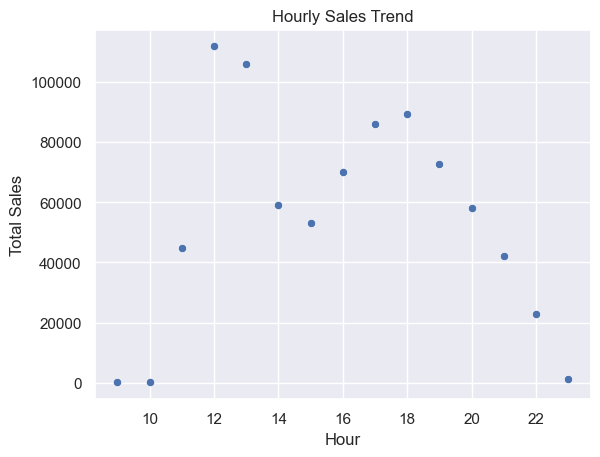

In [23]:
# Scatterplot of hourly sales trend
sns.scatterplot(
    data=ph,
    x="hour",
    y="sales"
)
plt.title("Hourly Sales Trend")
plt.xlabel("Hour")
plt.ylabel("Total Sales")
plt.show();

### Find the total sales made on each day of the week. Which day of the week is when sales are made the most?

In [24]:
# Make day_of_week ordered and categorical
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=days, ordered=True)

In [25]:
# Compute days with highest sales
dows = df.groupby("day_of_week")["sales"].sum().sort_values(ascending=False).reset_index()
print(f"{dows['day_of_week'][0]} is the day of week when sales are made the most.")

Friday is the day of week when sales are made the most.


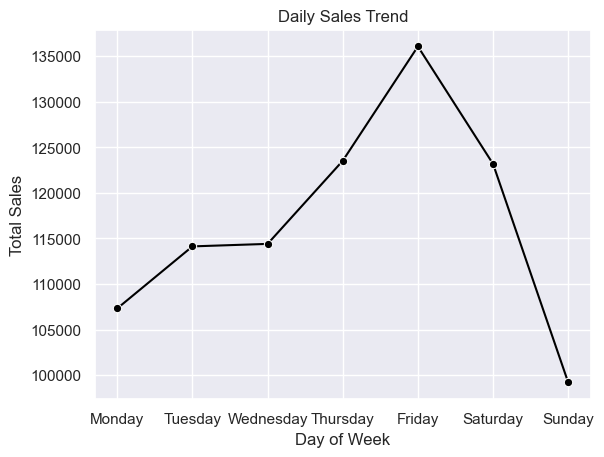

In [26]:
# Lineplot of daily sales trend
sns.lineplot(
    data=dows,
    x="day_of_week",
    y="sales",
    color="black",
    marker="o")
plt.title("Daily Sales Trend")
plt.xlabel("Day of Week")
plt.ylabel("Total Sales")
plt.show();

### Find the top 5 bestselling pizzas.


In [27]:
# Compute pizza types by sales
bsp = df.groupby("name")["sales"].sum().sort_values(ascending=False).reset_index()
print(f"The top 5 bestselling pizzas are \n- {bsp['name'][0]}, \n- {bsp['name'][1]}, \n- {bsp['name'][2]}, \n- {bsp['name'][3]}, and \n- {bsp['name'][4]}.")

The top 5 bestselling pizzas are 
- The Thai Chicken Pizza, 
- The Barbecue Chicken Pizza, 
- The California Chicken Pizza, 
- The Classic Deluxe Pizza, and 
- The Spicy Italian Pizza.


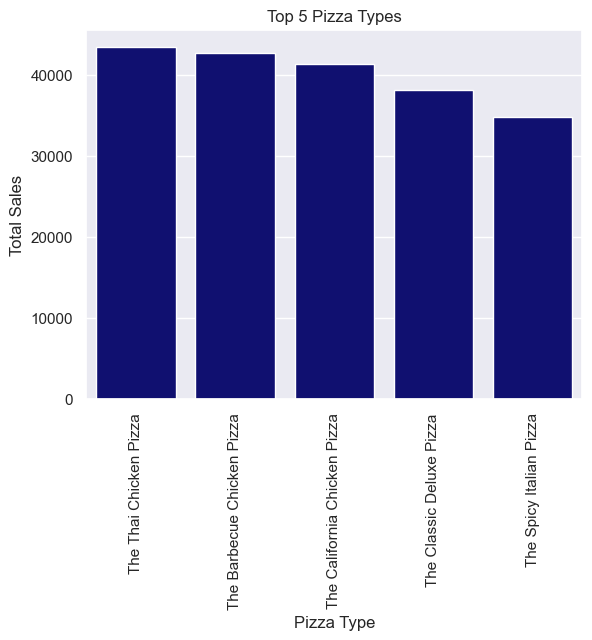

In [28]:
# Barplot of top 5 pizza types
sns.barplot(
    data=bsp.head(),
    x="name",
    y="sales",
    color="navy"
)
plt.title("Top 5 Pizza Types")
plt.xlabel("Pizza Type")
plt.xticks(rotation=90)
plt.ylabel("Total Sales")
plt.show();

### Find the sales made in each month. Any trend noticeable?

In [29]:
# Make month ordered and categorical
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df["month"] = pd.Categorical(df["month"], categories=months, ordered=True)

In [30]:
# Compute sales by months
spm = df.groupby("month").agg(Sales =("sales","sum")).reset_index()
spm

,month,Sales
0,January,69793.30
1,February,65159.60
2,March,70397.10
3,April,68736.80
4,May,71402.75
5,June,68230.20
6,July,72557.90
7,August,68278.25
8,September,64180.05
9,October,64027.60


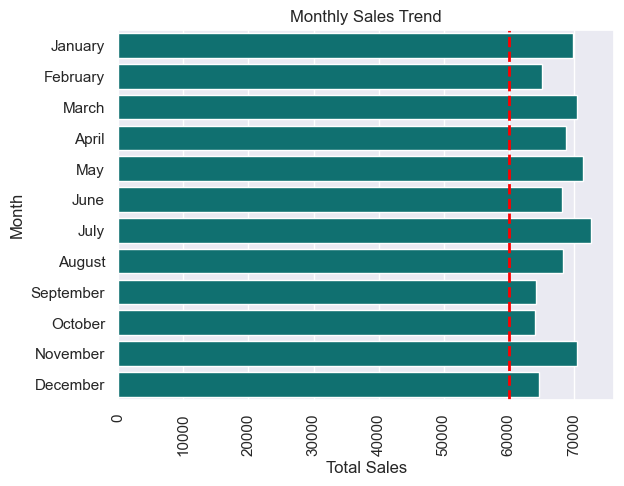

In [31]:
# Horizontal barplot of monthly sales trend with minimum threshhold
# Create horizontal barplot
sns.barplot(
    data=spm,
    x="Sales", 
    y="month",
    color="teal"
)

# Add threshhold line
plt.axvline(
    x=60000,
    color="red",
    linestyle="--",
    linewidth=2
)
plt.title("Monthly Sales Trend")
plt.xlabel("Total Sales")
plt.xticks(rotation=90)
plt.ylabel("Month")
plt.show();

The data shows that March, May, July, and November as months with high pizza demands.  
July is the peak pizza demand month. It probably is sheer coincidence that Independence Day  
is celebrated on July 4th of every year which could compel customers to buy more pizzas for gatherings.  
Demand does not go up during Christmas holiday month of December.  
It can be seen that despite downturns, sales does not go below `$60,000`.  
Perhaps more seasonal holiday promotions should target the winter holidays for more sales. 

### Are there pizza types that are not doing well on the menu?


In [32]:
# Least performing pizza types
print(f"The top 5 least selling pizzas are \n- {bsp['name'][27]}, \n- {bsp['name'][28]}, \n- {bsp['name'][29]}, \n- {bsp['name'][30]}, and \n- {bsp['name'][31]}.")

The top 5 least selling pizzas are 
- The Spinach Pesto Pizza, 
- The Mediterranean Pizza, 
- The Spinach Supreme Pizza, 
- The Green Garden Pizza, and 
- The Brie Carre Pizza.


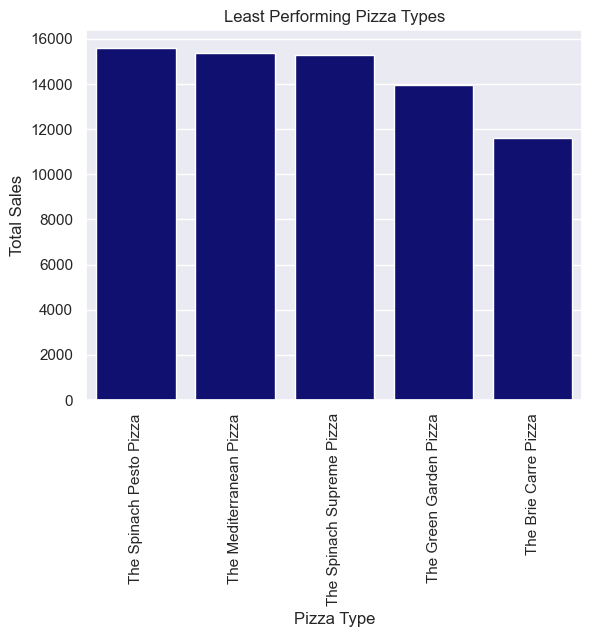

In [33]:
# Barplot of least performing pizza types
sns.barplot(
    data=bsp.tail(),
    x="name",
    y="sales",
    color="navy"
)
plt.title("Least Performing Pizza Types")
plt.xlabel("Pizza Type")
plt.xticks(rotation=90)
plt.ylabel("Total Sales")
plt.show();

### Top 20 Most Common Order Totals

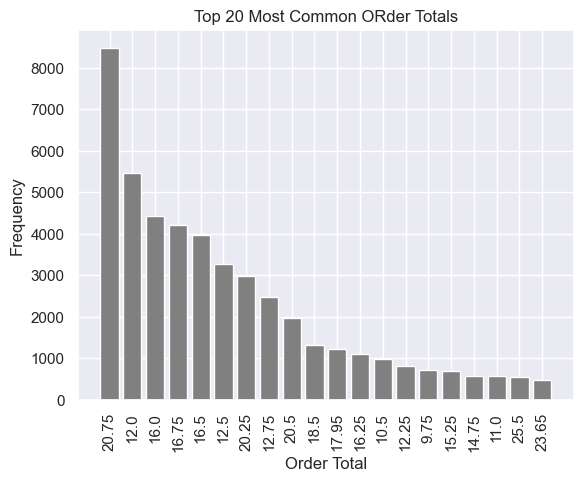

In [34]:
# Compute order values
ov = df["sales"].value_counts().head(20)

# Plot a bar chart of order values
plt.bar(
    ov.index.astype(str),
    ov.values,
    color="grey"
)
plt.title("Top 20 Most Common ORder Totals")
plt.xlabel("Order Total")
plt.xticks(rotation=90)
plt.ylabel("Frequency")
plt.show();

The data shows that $20.75 is the most common order/sales value.  
Even though the above are the most common order/sales values, there is no evidence from data that supports customers'  
preference for these specific values.

### Descriptive statistics of select numerical columns

In [35]:
# Compute descriptive statistics
desc = (
    df[["quantity", "price", "hour", "sales"]]
    .describe()
    .round(4)
    .style.background_gradient(cmap="Blues")
)
desc

,quantity,price,hour,sales
count,48620.000000,48620.000000,48620.000000,48620.000000
mean,1.019600,16.494100,15.911800,16.821500
std,0.143100,3.621800,3.149800,4.437400
min,1.000000,9.750000,9.000000,9.750000
25%,1.000000,12.750000,13.000000,12.750000
50%,1.000000,16.500000,16.000000,16.500000
75%,1.000000,20.250000,18.000000,20.500000
max,4.000000,35.950000,23.000000,83.000000


**COUNT:**  The dataframe contains 48,620 rows of data.  
**QUANTITY:** Although the data shows that some customers purchased up to 4 units  
of pizzas per order, approximately 1 unit of pizza was purchased per order  
with most other quartiles (including the median) mirroring the same value.  
**PRICE:** The data shows that the mean and median prices are quite close.  
But the mean calculated above differs from the actual mean (the result to  
the fifth question above) because the value in the descriptive statistics computes  
over the entire dataframe while the one computed above was estimated across the  
unique pizza types. Price ranged from `$9.75` to `$35.95`, with a mean price of '$16.50'.  
This shows that pizzas are moderately priced.  
**HOUR:** Orders were typically placed between 9:00am and before midnight daily with a  
median hour of 4:00pm. This shows that most orders were placed between afternoon and evening hours.  
**SALES:** Each sales value ranged from `$9.75` to `$83.00` with a median value of `$16.50`.

### Correlation Heatmap of numeric columns

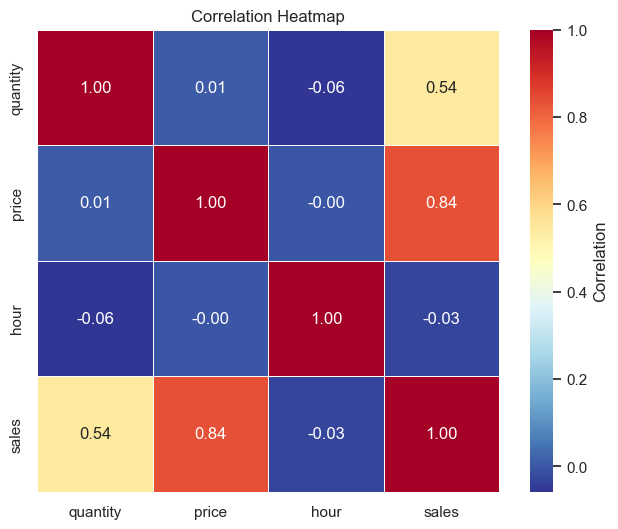

In [36]:
# Select numeric columns
df_numeric = df[["quantity", "price", "hour", "sales"]]

# Compute correlation matrix
corr = df_numeric.corr(numeric_only=True)

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlation"}
)
plt.title("Correlation Heatmap")
plt.show()

The heatmap above shows that Sales is moderately correlated with Quantity, highly correlated  
with Price, and a very low negative correlation with Hour. This is somewhat expected since Sales  
was computed based on Quantity and Price.  
Hour has a very low negative correlation with Quantity, and a near zero yet negative correlation with Price.  
This means that customers' spending behaviour is not determined by time.  
Price has a very low positive correlation with Quantity.

### Distribution of sales

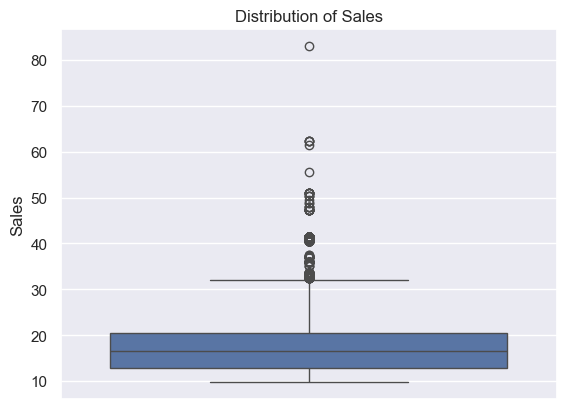

In [37]:
# Create boxplot of sales
sns.boxplot(df["sales"])
plt.title("Distribution of Sales")
plt.ylabel("Sales")
plt.show();

The boxplot shows that Sales values range from `$9.75` to `$83.00`.  
A large proportion of Sales occur between `$12.00` and `$20.75` (i.e between the 25th and 75th quartiles).  
While the lower whisker is at `$9.75`, the upper whisker seems to hold at the `$32.00` mark,  
beyond which are outlier values.

### Quantity of sales by size

In [38]:
# Compute quantity sold by size
size = df.groupby("size").agg(quantity=("quantity", "sum")).reset_index()

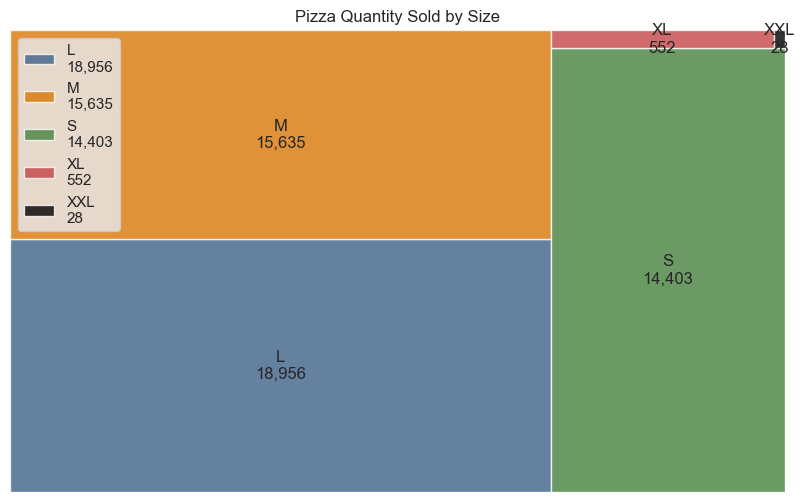

In [39]:
# Treemap of quantity of sales by size 

# Set size & quantity labels
labels = [
    f"{s}\n{q:,}"
    for s, q in zip(size["size"], size["quantity"])
]

# Set treemap colors
colors = ["#3E6288", "#D97706", "#46813F",  "#C44548",  "#000000"]

# Create Treemap using squarify
plt.figure(figsize=(10, 6))

sq.plot(
    sizes=size["quantity"],
    label=labels,
    color=colors,
    alpha=0.8,
    text_kwargs={"fontsize":12}
)
plt.title("Pizza Quantity Sold by Size")
plt.axis("off")
plt.legend()
plt.show()